# California CASTNET — Model Preparation (Step 4)

**Builds on:** `ca_feature_engineering.ipynb`  
**Outputs to:** `model_training.ipynb`

### Step 4 design decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Forecast horizons | **t+1, t+8, t+24** | t+8 maps directly to EPA NAAQS 8-hr standard; t+24 for day-ahead advisories |
| Multi-output strategy | **3 separate LightGBM models** | Feature importance shifts by horizon: lags dominate t+1, seasonality dominates t+24 |
| Train | **≤ 2018** | Full CARB regulatory baseline + 1990s–2000s decline; 28 years of site-specific structure |
| Val | **2019–2020** | Post-Campfire wildfire regime + 2020 COVID emission collapse — out-of-distribution stress test |
| Test | **2021–2025** | Post-COVID recovery + sustained wildfire era — deployment regime |
| Why not train_end=2019? | 2020 was anomalous; better as a **validation stress test** than noisy training signal |
| Classification target | **NAAQS_exceed_t8** — t+8 directly maps to the 8-hr standard |
| Boundary handling | Rows whose target window **crosses a split boundary are dropped** from that split |

### Sections
| # | Action |
|---|--------|
| 1–2 | Imports, CONFIG |
| 3 | Load Parquet feature store + metadata |
| 4 | Create multi-horizon targets (t+1, t+8, t+24) — no cross-site leakage |
| 5 | Temporal split with boundary-row exclusion |
| 6 | Data quality & leakage validation |
| 7 | LightGBM dataset construction + SITE_ID encoding |
| 8 | Persistence + climatology baselines |
| 9 | Train 3 regression models (one per horizon) |
| 10 | Train NAAQS exceedance classifier (t+8) |
| 11 | Per-horizon × per-site evaluation |
| 12 | Feature importance plots |
| 13 | Save models and evaluation artefacts |


## Section 1: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os
import gc
import pickle
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import dask.dataframe as dd
import lightgbm as lgb

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import LabelEncoder
from matplotlib.patches import Patch

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'lightgbm    : {lgb.__version__}')


pandas      : 2.2.2
numpy       : 1.26.4
lightgbm    : 4.6.0


## Section 2: Configuration

In [2]:
DATA_DIR   = r'C:\MATH699P\Data'
CA_DIR     = os.path.join(DATA_DIR, 'processed_data', 'california')
FE_DIR     = os.path.join(CA_DIR, 'features_parquet')
INPUT_PATH = os.path.join(FE_DIR, 'features_engineered')
META_PATH  = os.path.join(FE_DIR, 'ca_feature_metadata.pkl')
OUTPUT_DIR = os.path.join(FE_DIR, 'model_prep')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Feature store : {INPUT_PATH}')
print(f'Metadata      : {META_PATH}')
print(f'Output        : {OUTPUT_DIR}')


Feature store : C:\MATH699P\Data\processed_data\california\features_parquet\features_engineered
Metadata      : C:\MATH699P\Data\processed_data\california\features_parquet\ca_feature_metadata.pkl
Output        : C:\MATH699P\Data\processed_data\california\features_parquet\model_prep


In [3]:
# ── Temporal split ────────────────────────────────────────────────────────────
# Train : 1990–2018  Full CARB baseline + regulatory decline era (28 yrs)
# Val   : 2019–2020  Post-Campfire wildfire regime + COVID emission collapse
# Test  : 2021–2025  Post-COVID + sustained wildfire era (deployment regime)
CONFIG = {
    'train_end'    : '2018-12-31',
    'val_start'    : '2019-01-01',
    'val_end'      : '2020-12-31',
    'test_start'   : '2021-01-01',

    # ── Forecast horizons (hours ahead) ──────────────────────────────────────
    # t+1  : next-hour nowcast (operational dispatch)
    # t+8  : next 8-hr window  <- KEY: maps to EPA NAAQS 8-hr standard
    # t+24 : day-ahead advisory (public health alerts)
    'horizons'     : [1, 8, 24],
    'key_horizon'  : 8,

    # ── Regression hyperparameters (shared across horizons) ──────────────────
    'lgb_reg_params' : {
        'objective'        : 'regression_l1',  # MAE: robust to ozone spikes
        'metric'           : ['mae', 'rmse'],
        'num_leaves'       : 127,
        'max_depth'        : -1,
        'learning_rate'    : 0.05,
        'n_estimators'     : 2000,
        'min_child_samples': 30,
        'subsample'        : 0.8,
        'subsample_freq'   : 1,
        'colsample_bytree' : 0.7,
        'reg_alpha'        : 0.1,
        'reg_lambda'       : 1.0,
        'n_jobs'           : -1,
        'random_state'     : 42,
        'verbose'          : -1,
    },

    # ── Classification: NAAQS exceedance t+8 ────────────────────────────────
    'lgb_clf_params' : {
        'objective'        : 'binary',
        'metric'           : ['binary_logloss', 'auc'],
        'num_leaves'       : 63,
        'max_depth'        : -1,
        'learning_rate'    : 0.05,
        'n_estimators'     : 1000,
        'min_child_samples': 50,
        'subsample'        : 0.8,
        'subsample_freq'   : 1,
        'colsample_bytree' : 0.7,
        'scale_pos_weight' : 5,    # Exceedance is rare; upweight positives
        'n_jobs'           : -1,
        'random_state'     : 42,
        'verbose'          : -1,
    },

    'early_stopping_rounds' : 100,
    'naaqs_threshold'       : 70.0,
}

print('CONFIG:')
print(f'  Train  : start -> {CONFIG["train_end"]}')
print(f'  Val    : {CONFIG["val_start"]} -> {CONFIG["val_end"]}')
print(f'  Test   : {CONFIG["test_start"]} -> end')
print(f'  Horizons : {CONFIG["horizons"]} hours  (key: t+{CONFIG["key_horizon"]})')


CONFIG:
  Train  : start -> 2018-12-31
  Val    : 2019-01-01 -> 2020-12-31
  Test   : 2021-01-01 -> end
  Horizons : [1, 8, 24] hours  (key: t+8)


## Section 3: Load Feature Store & Metadata

In [4]:
with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)

FEATURE_COLS = meta['feature_cols']
ca_sites     = meta['ca_sites']
fe_config    = meta['fe_config']

print('Metadata loaded:')
print(f'  Features    : {len(FEATURE_COLS)}')
print(f'  Sites       : {len(ca_sites)}  {ca_sites}')
print(f'  Ozone range : {meta["ozone_date_range"]}')
print(f'  Total rows  : {meta["total_rows"]:,}')
if 'site_year_ranges' in meta:
    print('\n  Per-site year coverage:')
    for sid, yr in sorted(meta['site_year_ranges'].items()):
        print(f'    {sid}  {yr["min_year"]}–{yr["max_year"]}  ({yr["n_years"]} years)')


Metadata loaded:
  Features    : 101
  Sites       : 12  ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']
  Ozone range : ('1990-01-01 00:00:00', '2025-05-31 23:00:00')
  Total rows  : 1,960,605

  Per-site year coverage:
    CAN407  1995–2025  (31 years)
    CON186  2003–2011  (9 years)
    DEV412  1995–2025  (21 years)
    JOT403  1995–2025  (31 years)
    LAV410  1995–2025  (31 years)
    LPO010  2023–2025  (3 years)
    PIN414  1995–2025  (31 years)
    SEK402  1997–2004  (8 years)
    SEK430  2005–2025  (21 years)
    SND152  1990–2024  (35 years)
    YOS204  2012–2013  (2 years)
    YOS404  1995–2025  (31 years)


In [5]:
print('Loading feature Parquet...')
# pd.read_parquet handles both flat and hive-partitioned layouts correctly.
# dd.read_parquet hits a PyArrow version bug (KeyError: 'SITE_ID') when the
# store was written with partition_on=['SITE_ID'] (hive subdirectories).
# pd.read_parquet reconstructs the SITE_ID partition column automatically.
df = pd.read_parquet(INPUT_PATH, engine='pyarrow')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {len(df.columns)}')
print(f'  Memory  : {df.memory_usage(deep=True).sum()/(1024**2):.1f} MB')

if 'SITE_ID' not in df.columns:
    raise RuntimeError(
        'SITE_ID column missing after Parquet read — '
        'check that INPUT_PATH points to the features_engineered directory.'
    )

df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

# Deduplicate: hive-partitioned writes can produce multiple part files per
# SITE_ID directory, yielding duplicate (SITE_ID, DATE_TIME) rows on read.
# Keep the last occurrence (matches sort order — last written wins).
_n_before = len(df)
df = df.drop_duplicates(subset=['SITE_ID', 'DATE_TIME'], keep='last')
_n_dropped = _n_before - len(df)
if _n_dropped:
    print(f'  ⚠  Dropped {_n_dropped:,} duplicate (SITE_ID, DATE_TIME) rows from Parquet')
else:
    print('  No duplicate timestamps found.')

# Reconcile feature list against actual Parquet columns
missing_feats = [c for c in FEATURE_COLS if c not in df.columns]
if missing_feats:
    print(f'\n  {len(missing_feats)} feature cols in metadata but not in Parquet — trimming')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
else:
    print(f'\n  All {len(FEATURE_COLS)} feature columns present.')

print(f'\nSites: {sorted(df["SITE_ID"].unique())}')
print(f'Date range: {df["DATE_TIME"].min()} -> {df["DATE_TIME"].max()}')

Loading feature Parquet...
  Rows    : 3,921,210
  Columns : 104
  Memory  : 1342.5 MB
  ⚠  Dropped 1,960,605 duplicate (SITE_ID, DATE_TIME) rows from Parquet

  All 101 feature columns present.

Sites: ['CAN407', 'CON186', 'DEV412', 'JOT403', 'LAV410', 'LPO010', 'PIN414', 'SEK402', 'SEK430', 'SND152', 'YOS204', 'YOS404']
Date range: 1990-01-01 00:00:00 -> 2025-05-31 23:00:00


## Section 4: Create Multi-Horizon Forecast Targets

Targets are created **within each site group** using `.shift(-H)` to prevent
cross-site leakage. Rows with NaN targets (end-of-site gaps) are dropped at
split time.

**Boundary handling:** for horizon H, any row at time t whose target
OZONE[t+H] would cross a split boundary is flagged and excluded from that
split's dataset. This prevents the model from ever training on a target that
was measured after the split cutoff.

| Column | Meaning |
|--------|---------|
| `OZONE_t1` | OZONE at t+1h (regression target) |
| `OZONE_t8` | OZONE at t+8h (key regulatory horizon) |
| `OZONE_t24` | OZONE at t+24h (day-ahead) |
| `NAAQS_exceed_t8` | 1 if OZONE_t8 > 70 ppb (classification target) |


In [6]:
print('Creating multi-horizon targets per site...')
print('-' * 60)

train_end_ts = pd.Timestamp(CONFIG['train_end'])
val_end_ts   = pd.Timestamp(CONFIG['val_end'])

site_dfs = []
for sid, grp in df.groupby('SITE_ID'):
    grp = grp.sort_values('DATE_TIME').copy()

    for H in CONFIG['horizons']:
        col = f'OZONE_t{H}'
        grp[col] = grp['OZONE'].shift(-H).astype('float32')

        # Flag rows whose target window crosses a split boundary
        target_ts = grp['DATE_TIME'] + pd.Timedelta(hours=H)
        grp[f'_bnd_train_{H}'] = (
            (grp['DATE_TIME'] <= train_end_ts) & (target_ts > train_end_ts)
        )
        grp[f'_bnd_val_{H}'] = (
            (grp['DATE_TIME'] <= val_end_ts) & (target_ts > val_end_ts)
        )

    # Classification target: t+8 NAAQS exceedance
    if 'OZONE_t8' in grp.columns:
        grp['NAAQS_exceed_t8'] = (
            grp['OZONE_t8'] > CONFIG['naaqs_threshold']
        ).astype('float32')

    site_dfs.append(grp)

df = pd.concat(site_dfs, ignore_index=True)
df = df.sort_values(['SITE_ID', 'DATE_TIME']).reset_index(drop=True)

for H in CONFIG['horizons']:
    col     = f'OZONE_t{H}'
    n_valid = df[col].notna().sum()
    n_bnd   = (df[f'_bnd_train_{H}'].sum() + df[f'_bnd_val_{H}'].sum())
    print(f'  t+{H:2d}h  {col:<12s}  valid: {n_valid:,}  boundary rows: {n_bnd:,}')

naaqs_rate = df['NAAQS_exceed_t8'].mean() * 100
print(f'\n  NAAQS_exceed_t8 base rate: {naaqs_rate:.2f}%')
print(f'  scale_pos_weight in clf: {CONFIG["lgb_clf_params"]["scale_pos_weight"]}')


Creating multi-horizon targets per site...
------------------------------------------------------------
  t+ 1h  OZONE_t1      valid: 1,960,593  boundary rows: 15
  t+ 8h  OZONE_t8      valid: 1,960,509  boundary rows: 120
  t+24h  OZONE_t24     valid: 1,960,317  boundary rows: 356

  NAAQS_exceed_t8 base rate: 4.10%
  scale_pos_weight in clf: 5


## Section 5: Temporal Split

**Why this split for California:**
- **Train ≤2018**: Captures the full CARB regulatory baseline, the steep 1990s–2000s
  ozone decline, and 28+ years of site-specific seasonality.
- **Val 2019–2020**: 2019 marks the post-Campfire wildfire PM2.5 regime. 2020 adds
  simultaneous COVID emission collapse + record fires — exactly the kind of
  out-of-distribution conditions to stress-test the model against.
- **Test 2021–2025**: Clean post-COVID baseline with continued wildfire activity.
  This is the regime the model will be deployed in.


In [7]:
def make_split(df, split_name, date_start, date_end, horizons, feature_cols):
    """
    Extract one temporal split for all horizons.
    Drops boundary rows (target crosses split boundary) and NaN targets.
    Returns dict {H: (X, y_reg, y_clf, meta_df)}.
    """
    mask_time = pd.Series(True, index=df.index)
    if date_start:
        mask_time &= df['DATE_TIME'] >= pd.Timestamp(date_start)
    if date_end:
        mask_time &= df['DATE_TIME'] <= pd.Timestamp(date_end)

    splits = {}
    for H in horizons:
        bnd_col = (f'_bnd_train_{H}' if split_name == 'train'
                   else f'_bnd_val_{H}' if split_name == 'val'
                   else None)

        mask = mask_time.copy()
        if bnd_col and bnd_col in df.columns:
            mask &= ~df[bnd_col]

        target_col = f'OZONE_t{H}'
        clf_col    = 'NAAQS_exceed_t8' if H == CONFIG['key_horizon'] else None

        sub = df[mask & df[target_col].notna()].copy()

        X     = sub[feature_cols].copy()
        y_reg = sub[target_col].copy()
        y_clf = sub[clf_col].copy() if clf_col and clf_col in sub.columns else None
        meta  = sub[['SITE_ID', 'DATE_TIME', target_col]].copy()

        splits[H] = (X, y_reg, y_clf, meta)
    return splits


train_splits = make_split(df, 'train', None,
                          CONFIG['train_end'],  CONFIG['horizons'], FEATURE_COLS)
val_splits   = make_split(df, 'val',   CONFIG['val_start'],
                          CONFIG['val_end'],    CONFIG['horizons'], FEATURE_COLS)
test_splits  = make_split(df, 'test',  CONFIG['test_start'],
                          None,                CONFIG['horizons'], FEATURE_COLS)

print('Temporal Split Summary')
print('=' * 80)
print(f'  {"Split":<6}  {"Horizon":>8}  {"Rows":>10}  {"Sites":>6}  '
      f'{"NAAQS=1":>9}  Date range')
print('-' * 80)
for sname, sp in [("train", train_splits), ("val", val_splits), ("test", test_splits)]:
    for H in CONFIG['horizons']:
        X, y_reg, y_clf, meta = sp[H]
        sites = meta['SITE_ID'].nunique()
        naaqs = f'{y_clf.mean()*100:.1f}%' if y_clf is not None and len(y_clf) > 0 else '—'
        dr    = (f'{meta["DATE_TIME"].min().date()} -> '
                 f'{meta["DATE_TIME"].max().date()}')
        print(f'  {sname:<6}  t+{H:>2d}h     {len(X):>10,}  '
              f'{sites:>6}  {naaqs:>9}  {dr}')
    print()


Temporal Split Summary
  Split    Horizon        Rows   Sites    NAAQS=1  Date range
--------------------------------------------------------------------------------
  train   t+ 1h      1,529,576      11          —  1990-01-01 -> 2018-12-30
  train   t+ 8h      1,529,506      11       4.8%  1990-01-01 -> 2018-12-30
  train   t+24h      1,529,348      11          —  1990-01-01 -> 2018-12-30

  val     t+ 1h        132,535       8          —  2019-01-01 -> 2020-12-30
  val     t+ 8h        132,479       8       1.8%  2019-01-01 -> 2020-12-30
  val     t+24h        132,353       8          —  2019-01-01 -> 2020-12-30

  test    t+ 1h        298,126       9          —  2021-01-01 -> 2025-05-31
  test    t+ 8h        298,063       9       1.6%  2021-01-01 -> 2025-05-31
  test    t+24h        297,919       9          —  2021-01-01 -> 2025-05-30



## Section 6: Data Quality & Leakage Validation

In [8]:
print('=== DATA QUALITY CHECKS ===')
print()

# 1. Missing values in training features (t+1 proxy for all horizons)
X_tr1, y_tr1, _, meta_tr1 = train_splits[1]
miss_rate = X_tr1.isnull().mean().sort_values(ascending=False)
high_miss  = miss_rate[miss_rate > 0.05]
print(f'Features with >5% missing in train: {len(high_miss)}')
if not high_miss.empty:
    print(high_miss.head(10).to_string())
else:
    print('  No features exceed 5% missing in training set')

# 2. Target distribution per split (t+8)
print(f'\nOZONE_t8 distribution by split:')
print(f'  {"Split":<6}  {"Mean":>7}  {"Std":>7}  {"p10":>7}  '
      f'{"p50":>7}  {"p90":>7}  {"Max":>7}')
print('-' * 60)
for sname, sp in [("train", train_splits), ("val", val_splits), ("test", test_splits)]:
    y = sp[8][1]
    print(f'  {sname:<6}  {y.mean():>7.2f}  {y.std():>7.2f}  '
          f'{y.quantile(.10):>7.2f}  {y.quantile(.50):>7.2f}  '
          f'{y.quantile(.90):>7.2f}  {y.max():>7.2f}')

# 3. Temporal leakage check
print('\nLeakage check:')
tr_max = meta_tr1['DATE_TIME'].max()
vl_min = val_splits[1][3]['DATE_TIME'].min()
te_min = test_splits[1][3]['DATE_TIME'].min()
ok1 = tr_max <= pd.Timestamp(CONFIG['train_end']) + pd.Timedelta(hours=1)
ok2 = vl_min >= pd.Timestamp(CONFIG['val_start'])
ok3 = te_min >= pd.Timestamp(CONFIG['test_start'])
print(f'  Train max date : {tr_max}  {"" if ok1 else "LEAKAGE"}')
print(f'  Val min date   : {vl_min}  {"" if ok2 else "LEAKAGE"}')
print(f'  Test min date  : {te_min}  {"" if ok3 else "LEAKAGE"}')

# 4. Horizon target correlations — sanity check degradation with horizon
print('\nTarget correlation with current OZONE (should decrease with horizon):')
cur_ozone = df.set_index(['SITE_ID','DATE_TIME'])['OZONE']
for H in CONFIG['horizons']:
    X_t, y_t, _, m_t = train_splits[H]
    sub = df.loc[df['DATE_TIME'].isin(m_t['DATE_TIME'])]
    r = np.corrcoef(sub['OZONE'].values[:len(y_t)], y_t.values)[0,1]
    print(f'  t+{H:>2d}h  r={r:.4f}')


=== DATA QUALITY CHECKS ===

Features with >5% missing in train: 5
fire_km2_active_7d_50km      0.1867
fire_km2_active_30d_50km     0.1867
fire_km2_active_today_50km   0.1867
n_active_fires_today_50km    0.1867
fire_km2_active_90d_50km     0.1867

OZONE_t8 distribution by split:
  Split      Mean      Std      p10      p50      p90      Max
------------------------------------------------------------
  train     43.12    15.71    23.00    43.00    63.00   108.00
  val       40.41    13.42    23.00    41.00    57.00    93.00
  test      41.59    13.17    25.00    42.00    57.00    93.00

Leakage check:
  Train max date : 2018-12-30 23:00:00  
  Val min date   : 2019-01-01 00:00:00  
  Test min date  : 2021-01-01 00:00:00  

Target correlation with current OZONE (should decrease with horizon):
  t+ 1h  r=0.8944
  t+ 8h  r=0.6252
  t+24h  r=0.6593


## Section 7: LightGBM Dataset Construction

One `lgb.Dataset` pair (train + val) per horizon. `SITE_ID` is integer-encoded
and appended as a feature so the model learns site-specific ozone baselines
without one-hot overhead. Training medians are saved to disk for inference.


In [9]:
# SITE_ID integer encoder (fit on all sites, stable across splits)
le_site = LabelEncoder()
le_site.fit(sorted(df['SITE_ID'].unique()))

FEATURE_COLS_EXT = FEATURE_COLS + ['SITE_ID_enc']


def add_site_enc(X, meta):
    """Append integer-encoded SITE_ID column to feature matrix."""
    X = X.copy()
    X['SITE_ID_enc'] = le_site.transform(meta['SITE_ID'].values).astype('int8')
    return X


lgb_data = {}  # {H: dict with train/val datasets + medians}

for H in CONFIG['horizons']:
    X_tr, y_tr, _, m_tr = train_splits[H]
    X_vl, y_vl, _, m_vl = val_splits[H]

    X_tr = add_site_enc(X_tr, m_tr)
    X_vl = add_site_enc(X_vl, m_vl)

    # Impute remaining NaN with training medians
    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_vl = X_vl.fillna(medians)

    dtrain = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
    dval   = lgb.Dataset(X_vl, label=y_vl, reference=dtrain, free_raw_data=False)

    lgb_data[H] = {
        'train'    : dtrain, 'val'     : dval,
        'X_train'  : X_tr,   'X_val'   : X_vl,
        'y_train'  : y_tr,   'y_val'   : y_vl,
        'medians'  : medians,
        'meta_train': m_tr,  'meta_val': m_vl,
    }
    print(f'  t+{H:2d}h  train: {len(X_tr):,}  val: {len(X_vl):,}  '
          f'features: {X_tr.shape[1]}')

# Classification dataset (t+8)
X_tr8, _, y_tr8c, m_tr8 = train_splits[CONFIG['key_horizon']]
X_vl8, _, y_vl8c, m_vl8 = val_splits[CONFIG['key_horizon']]
X_tr8 = add_site_enc(X_tr8, m_tr8).fillna(lgb_data[8]['medians'])
X_vl8 = add_site_enc(X_vl8, m_vl8).fillna(lgb_data[8]['medians'])

if y_tr8c is not None:
    dtrain_clf = lgb.Dataset(X_tr8, label=y_tr8c, free_raw_data=False)
    dval_clf   = lgb.Dataset(X_vl8, label=y_vl8c,
                             reference=dtrain_clf, free_raw_data=False)
    print(f'\n  clf t+8  train pos: {y_tr8c.mean()*100:.2f}%  '
          f'val pos: {y_vl8c.mean()*100:.2f}%')
else:
    dtrain_clf = dval_clf = None
    print('NAAQS_exceed_t8 not available — classification skipped')

# Save training medians + encoder for inference
# Per-horizon medians saved: each horizon's training split has slightly different
# boundary-row exclusions. Step 5 (california_models.ipynb) uses horizon-matched
# medians for correct imputation rather than always defaulting to t+1 medians.
med_path = os.path.join(OUTPUT_DIR, 'train_medians.pkl')
with open(med_path, 'wb') as f:
    pickle.dump({
        'medians'     : {H: lgb_data[H]['medians'] for H in CONFIG['horizons']},
        'feature_cols': FEATURE_COLS_EXT,
        'site_encoder': le_site,
    }, f)
print(f'\nInference artefacts saved -> {med_path}')


  t+ 1h  train: 1,529,576  val: 132,535  features: 102
  t+ 8h  train: 1,529,506  val: 132,479  features: 102
  t+24h  train: 1,529,348  val: 132,353  features: 102

  clf t+8  train pos: 4.78%  val pos: 1.78%

Inference artefacts saved -> C:\MATH699P\Data\processed_data\california\features_parquet\model_prep\train_medians.pkl


## Section 8: Baseline Models

Two baselines establish the performance floor LightGBM must beat:

1. **Persistence** — predict OZONE[t+H] = OZONE[t]. Strongest naive baseline for
   short horizons; degrades sharply at t+24 because diurnal cycles reset overnight.
2. **Climatology** — predict the training-set mean for this (site, month, hour).
   Captures seasonal and diurnal signals but ignores current atmospheric state;
   competitive at t+24 where persistence has collapsed.


In [10]:
# Build climatology from training data: mean by (SITE_ID, month, hour)
clim_df  = df[df['DATE_TIME'] <= pd.Timestamp(CONFIG['train_end'])].copy()
clim_map = (
    clim_df.groupby(['SITE_ID', 'month', 'hour'])['OZONE']
           .mean().rename('clim_mean').reset_index()
)

baseline_results = {}
print('Baselines on validation set')
print('=' * 65)

for H in CONFIG['horizons']:
    X_vl, y_vl, _, m_vl = val_splits[H]

    # validate='m:1' ensures df has unique (SITE_ID, DATE_TIME) — raises
    # MergeError immediately if any fanout survives the dedup above.
    val_meta = m_vl.merge(
        df[['SITE_ID', 'DATE_TIME', 'OZONE', 'month', 'hour']]
          .drop_duplicates(subset=['SITE_ID', 'DATE_TIME']),
        on=['SITE_ID', 'DATE_TIME'], how='left', validate='m:1'
    ).merge(clim_map, on=['SITE_ID', 'month', 'hour'], how='left')

    val_meta['clim_mean'] = val_meta['clim_mean'].fillna(
        clim_df['OZONE'].mean()
    )

    y_true   = y_vl.values
    pred_p   = val_meta['OZONE'].values     # persistence
    pred_c   = val_meta['clim_mean'].values # climatology
    mask     = ~np.isnan(y_true) & ~np.isnan(pred_p)

    mae_p  = mean_absolute_error(y_true[mask], pred_p[mask])
    rmse_p = np.sqrt(mean_squared_error(y_true[mask], pred_p[mask]))
    r2_p   = r2_score(y_true[mask], pred_p[mask])

    mae_c  = mean_absolute_error(y_true[mask], pred_c[mask])
    rmse_c = np.sqrt(mean_squared_error(y_true[mask], pred_c[mask]))
    r2_c   = r2_score(y_true[mask], pred_c[mask])

    baseline_results[H] = {
        'persistence' : {'mae': mae_p, 'rmse': rmse_p, 'r2': r2_p},
        'climatology' : {'mae': mae_c, 'rmse': rmse_c, 'r2': r2_c},
    }
    print(f'  t+{H:2d}h  Persistence  MAE={mae_p:.3f}  RMSE={rmse_p:.3f}  R2={r2_p:.4f}')
    print(f'         Climatology  MAE={mae_c:.3f}  RMSE={rmse_c:.3f}  R2={r2_c:.4f}')
    print()

Baselines on validation set
  t+ 1h  Persistence  MAE=2.100  RMSE=3.305  R2=0.9393
         Climatology  MAE=7.125  RMSE=9.264  R2=0.5231

  t+ 8h  Persistence  MAE=9.048  RMSE=12.537  R2=0.1267
         Climatology  MAE=10.567  RMSE=14.128  R2=-0.1091

  t+24h  Persistence  MAE=6.301  RMSE=8.600  R2=0.5891
         Climatology  MAE=7.154  RMSE=9.344  R2=0.5149



## Section 9: Train LightGBM Regression Models (t+1, t+8, t+24)

Three independent models, one per horizon. Sharing a single model forces a
compromise that is suboptimal: at t+1, recent ozone lags dominate; at t+24,
temporal/seasonal features and `ozone_annual_site_mean` dominate. Separate
models capture this cleanly and allow horizon-specific hyperparameter tuning.

Early stopping monitors MAE on the validation set. The best iteration is
preserved and used for all downstream inference.


In [11]:
reg_models = {}  # {H: lgb.Booster}
reg_eval   = {}  # {H: {split: {metric: value}}}

callbacks = [
    lgb.early_stopping(CONFIG['early_stopping_rounds'], verbose=False),
    lgb.log_evaluation(200),
]

print('Training LightGBM regression models...')
print('=' * 70)

for H in CONFIG['horizons']:
    print(f'\n── Horizon t+{H}h ──────────────────────────────────────────────────')
    t0 = datetime.now()

    model = lgb.train(
        params      = CONFIG['lgb_reg_params'],
        train_set   = lgb_data[H]['train'],
        valid_sets  = [lgb_data[H]['train'], lgb_data[H]['val']],
        valid_names = ['train', 'val'],
        callbacks   = callbacks,
    )
    elapsed = (datetime.now() - t0).total_seconds()
    reg_models[H] = model
    reg_eval[H]   = {}

    for sname, sp in [('val', val_splits), ('test', test_splits)]:
        X_sp, y_sp, _, m_sp = sp[H]
        X_sp  = add_site_enc(X_sp, m_sp).fillna(lgb_data[H]['medians'])
        y_hat = model.predict(X_sp)
        y_true = y_sp.values
        mask  = ~np.isnan(y_true)

        mae  = mean_absolute_error(y_true[mask], y_hat[mask])
        rmse = np.sqrt(mean_squared_error(y_true[mask], y_hat[mask]))
        r2   = r2_score(y_true[mask], y_hat[mask])
        reg_eval[H][sname] = {'mae': mae, 'rmse': rmse, 'r2': r2}
        print(f'  {sname:<5}  MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}')

    print(f'  Best iter: {model.best_iteration}  |  Time: {elapsed:.1f}s')
    gc.collect()

# Summary vs baselines
print('\n' + '=' * 80)
print(f'  {"Horizon":<10}  {"Split":<5}  {"MAE":>8}  {"vs Persist":>11}  '
      f'{"vs Clim":>9}  {"R2":>8}')
print('-' * 65)
for H in CONFIG['horizons']:
    bp = baseline_results[H]['persistence']['mae']
    bc = baseline_results[H]['climatology']['mae']
    for sname in ['val', 'test']:
        m_mae = reg_eval[H][sname]['mae']
        m_r2  = reg_eval[H][sname]['r2']
        vp = f'{(1-m_mae/bp)*100:+.1f}%' if sname == 'val' else '—'
        vc = f'{(1-m_mae/bc)*100:+.1f}%' if sname == 'val' else '—'
        print(f'  t+{H:>2d}h      {sname:<5}  {m_mae:>8.3f}  {vp:>11}  {vc:>9}  {m_r2:>8.4f}')
    print()


Training LightGBM regression models...

── Horizon t+1h ──────────────────────────────────────────────────
[200]	train's l1: 1.97023	train's rmse: 3.09046	val's l1: 1.68429	val's rmse: 2.57473
[400]	train's l1: 1.93159	train's rmse: 3.04082	val's l1: 1.66527	val's rmse: 2.54478
[600]	train's l1: 1.90816	train's rmse: 3.01288	val's l1: 1.65758	val's rmse: 2.5323
[800]	train's l1: 1.89121	train's rmse: 2.99422	val's l1: 1.65386	val's rmse: 2.52617
[1000]	train's l1: 1.87596	train's rmse: 2.97755	val's l1: 1.6513	val's rmse: 2.52126
[1200]	train's l1: 1.86331	train's rmse: 2.96472	val's l1: 1.6497	val's rmse: 2.51847
[1400]	train's l1: 1.85189	train's rmse: 2.95263	val's l1: 1.6487	val's rmse: 2.51653
[1600]	train's l1: 1.84192	train's rmse: 2.9421	val's l1: 1.64802	val's rmse: 2.51512
[1800]	train's l1: 1.83131	train's rmse: 2.93136	val's l1: 1.6472	val's rmse: 2.51355
[2000]	train's l1: 1.82088	train's rmse: 2.92093	val's l1: 1.64644	val's rmse: 2.5118
  val    MAE=1.646  RMSE=2.512  R2

## Section 10: NAAQS Exceedance Classification (t+8)

A dedicated binary classifier for: *will the 8-hour window starting now exceed
70 ppb?* A classifier outperforms thresholding the regression output because:
- The loss function directly optimises precision/recall at the decision boundary
- `scale_pos_weight` upweights the rare exceedance class
- The classifier learns that some feature combinations that produce high ozone
  are unreliable predictors of *regulatory* exceedance specifically

The decision threshold is chosen by **maximising F1 on the validation set**
(not fixed at 0.5), then applied to the test set.


In [12]:
clf_model = None
clf_eval  = {}
best_thr  = 0.5

if dtrain_clf is not None:
    print('Training NAAQS exceedance classifier (t+8)...')
    print('=' * 60)

    clf_model = lgb.train(
        params      = CONFIG['lgb_clf_params'],
        train_set   = dtrain_clf,
        valid_sets  = [dtrain_clf, dval_clf],
        valid_names = ['train', 'val'],
        callbacks   = callbacks,
    )

    # Find optimal threshold: maximise F1 on validation set
    val_proba  = clf_model.predict(X_vl8)
    y_vl8_arr  = y_vl8c.values
    prec, rec, thr = precision_recall_curve(y_vl8_arr, val_proba)
    f1s     = 2 * prec * rec / (prec + rec + 1e-10)
    best_idx = f1s[:-1].argmax()
    best_thr = float(thr[best_idx])

    val_auc  = roc_auc_score(y_vl8_arr, val_proba)
    val_ap   = average_precision_score(y_vl8_arr, val_proba)
    val_pred = (val_proba >= best_thr).astype(int)
    val_f1   = f1_score(y_vl8_arr, val_pred)

    print(f'\n  Optimal threshold (max-F1 on val) : {best_thr:.3f}')
    print(f'  Val AUC-ROC          : {val_auc:.4f}')
    print(f'  Val Avg Precision    : {val_ap:.4f}')
    print(f'  Val F1 @ threshold   : {val_f1:.4f}')

    print(f'\nValidation classification report (thr={best_thr:.3f}):')
    print(classification_report(y_vl8_arr, val_pred,
                                target_names=['No exceed', 'Exceed'], digits=4))

    # Test set evaluation
    X_te8, _, y_te8c, m_te8 = test_splits[CONFIG['key_horizon']]
    X_te8     = add_site_enc(X_te8, m_te8).fillna(lgb_data[8]['medians'])
    test_proba = clf_model.predict(X_te8)
    test_pred  = (test_proba >= best_thr).astype(int)
    y_te8_arr  = y_te8c.values if y_te8c is not None else np.zeros(len(X_te8))

    te_auc = roc_auc_score(y_te8_arr, test_proba) if y_te8_arr.sum() > 0 else None
    te_ap  = average_precision_score(y_te8_arr, test_proba) if y_te8_arr.sum() > 0 else None
    te_f1  = f1_score(y_te8_arr, test_pred) if y_te8_arr.sum() > 0 else None

    clf_eval = {
        'best_threshold': best_thr,
        'val':  {'auc': val_auc,  'avg_prec': val_ap,  'f1': val_f1},
        'test': {'auc': te_auc,   'avg_prec': te_ap,   'f1': te_f1},
    }

    print('\nTest classification results:')
    for k, v in clf_eval['test'].items():
        val_str = f'{v:.4f}' if v is not None else 'N/A'
        print(f'  {k:<15s}: {val_str}')

    print(f'\nTest classification report (thr={best_thr:.3f}):')
    print(classification_report(y_te8_arr, test_pred,
                                target_names=['No exceed', 'Exceed'], digits=4))
else:
    print('NAAQS classification target not available — skipping')


Training NAAQS exceedance classifier (t+8)...
[200]	train's binary_logloss: 0.100537	train's auc: 0.983297	val's binary_logloss: 0.0517006	val's auc: 0.986191

  Optimal threshold (max-F1 on val) : 0.713
  Val AUC-ROC          : 0.9863
  Val Avg Precision    : 0.6488
  Val F1 @ threshold   : 0.6079

Validation classification report (thr=0.713):
              precision    recall  f1-score   support

   No exceed     0.9931    0.9923    0.9927    130125
      Exceed     0.5950    0.6215    0.6079      2354

    accuracy                         0.9858    132479
   macro avg     0.7941    0.8069    0.8003    132479
weighted avg     0.9861    0.9858    0.9859    132479


Test classification results:
  auc            : 0.9853
  avg_prec       : 0.6247
  f1             : 0.5799

Test classification report (thr=0.713):
              precision    recall  f1-score   support

   No exceed     0.9928    0.9934    0.9931    293172
      Exceed     0.5903    0.5698    0.5799      4891

    accuracy 

## Section 11: Per-Horizon × Per-Site Evaluation (Test Set)

In [13]:
print('Per-site evaluation on TEST set')
print('=' * 80)

site_eval = {}  # {H: {sid: {metric: value}}}

for H in CONFIG['horizons']:
    X_te, y_te, _, m_te = test_splits[H]
    X_te  = add_site_enc(X_te, m_te).fillna(lgb_data[H]['medians'])
    y_hat = reg_models[H].predict(X_te)
    m_te  = m_te.copy()
    m_te['y_hat'] = y_hat

    site_eval[H] = {}
    target_col   = f'OZONE_t{H}'
    print(f'\nt+{H}h  {"SITE_ID":<8}  {"MAE":>7}  {"RMSE":>7}  {"R2":>7}  {"N":>8}')
    print('-' * 50)
    for sid, grp in m_te.groupby('SITE_ID'):
        y_true = grp[target_col].values
        y_pred = grp['y_hat'].values
        mask   = ~np.isnan(y_true)
        if mask.sum() < 10:
            continue
        mae  = mean_absolute_error(y_true[mask], y_pred[mask])
        rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
        r2   = r2_score(y_true[mask], y_pred[mask])
        site_eval[H][sid] = {'mae': mae, 'rmse': rmse, 'r2': r2, 'n': mask.sum()}
        print(f'       {sid:<8}  {mae:>7.3f}  {rmse:>7.3f}  {r2:>7.4f}  {mask.sum():>8,}')


Per-site evaluation on TEST set

t+1h  SITE_ID       MAE     RMSE       R2         N
--------------------------------------------------
       CAN407      1.167    1.669   0.9580    36,965
       DEV412      1.076    1.558   0.9715    36,823
       JOT403      1.574    2.464   0.9466    35,419
       LAV410      2.034    3.003   0.8936    34,685
       LPO010      1.701    2.669   0.9231    12,495
       PIN414      1.953    2.941   0.9595    36,450
       SEK430      1.824    2.652   0.9772    36,589
       SND152      2.069    3.085   0.9334    31,629
       YOS404      1.342    1.930   0.9514    37,071

t+8h  SITE_ID       MAE     RMSE       R2         N
--------------------------------------------------
       CAN407      3.039    3.987   0.7604    36,958
       DEV412      2.892    4.015   0.8108    36,816
       JOT403      4.250    5.986   0.6847    35,412
       LAV410      4.760    6.250   0.5392    34,678
       LPO010      4.815    6.544   0.5377    12,488
       PIN414     

Saved -> C:\MATH699P\Data\processed_data\california\features_parquet\model_prep\horizon_eval_by_site.png


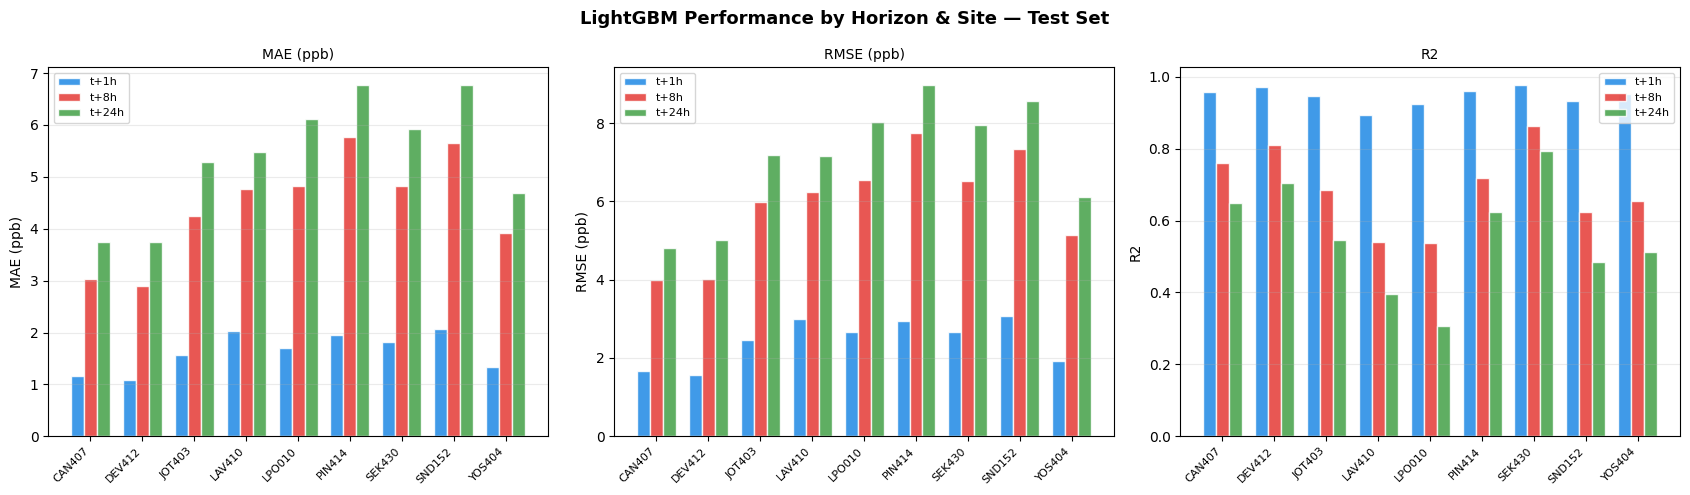

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('LightGBM Performance by Horizon & Site — Test Set',
             fontsize=13, fontweight='bold')

for ax, (metric, ylabel) in zip(axes,
        [('mae','MAE (ppb)'), ('rmse','RMSE (ppb)'), ('r2','R2')]):
    sites   = sorted(site_eval[CONFIG['horizons'][0]].keys())
    x       = np.arange(len(sites))
    w       = 0.25
    colors  = ['#1E88E5', '#E53935', '#43A047']
    for i, H in enumerate(CONFIG['horizons']):
        vals = [site_eval[H].get(s, {}).get(metric, np.nan) for s in sites]
        ax.bar(x + i*w, vals, w, label=f't+{H}h',
               color=colors[i], alpha=0.85, edgecolor='white')
    ax.set_xticks(x + w)
    ax.set_xticklabels(sites, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
eval_fig = os.path.join(OUTPUT_DIR, 'horizon_eval_by_site.png')
plt.savefig(eval_fig, dpi=150, bbox_inches='tight')
print(f'Saved -> {eval_fig}')
plt.show()


## Section 12: Feature Importance by Horizon

Saved -> C:\MATH699P\Data\processed_data\california\features_parquet\model_prep\feature_importance_by_horizon.png


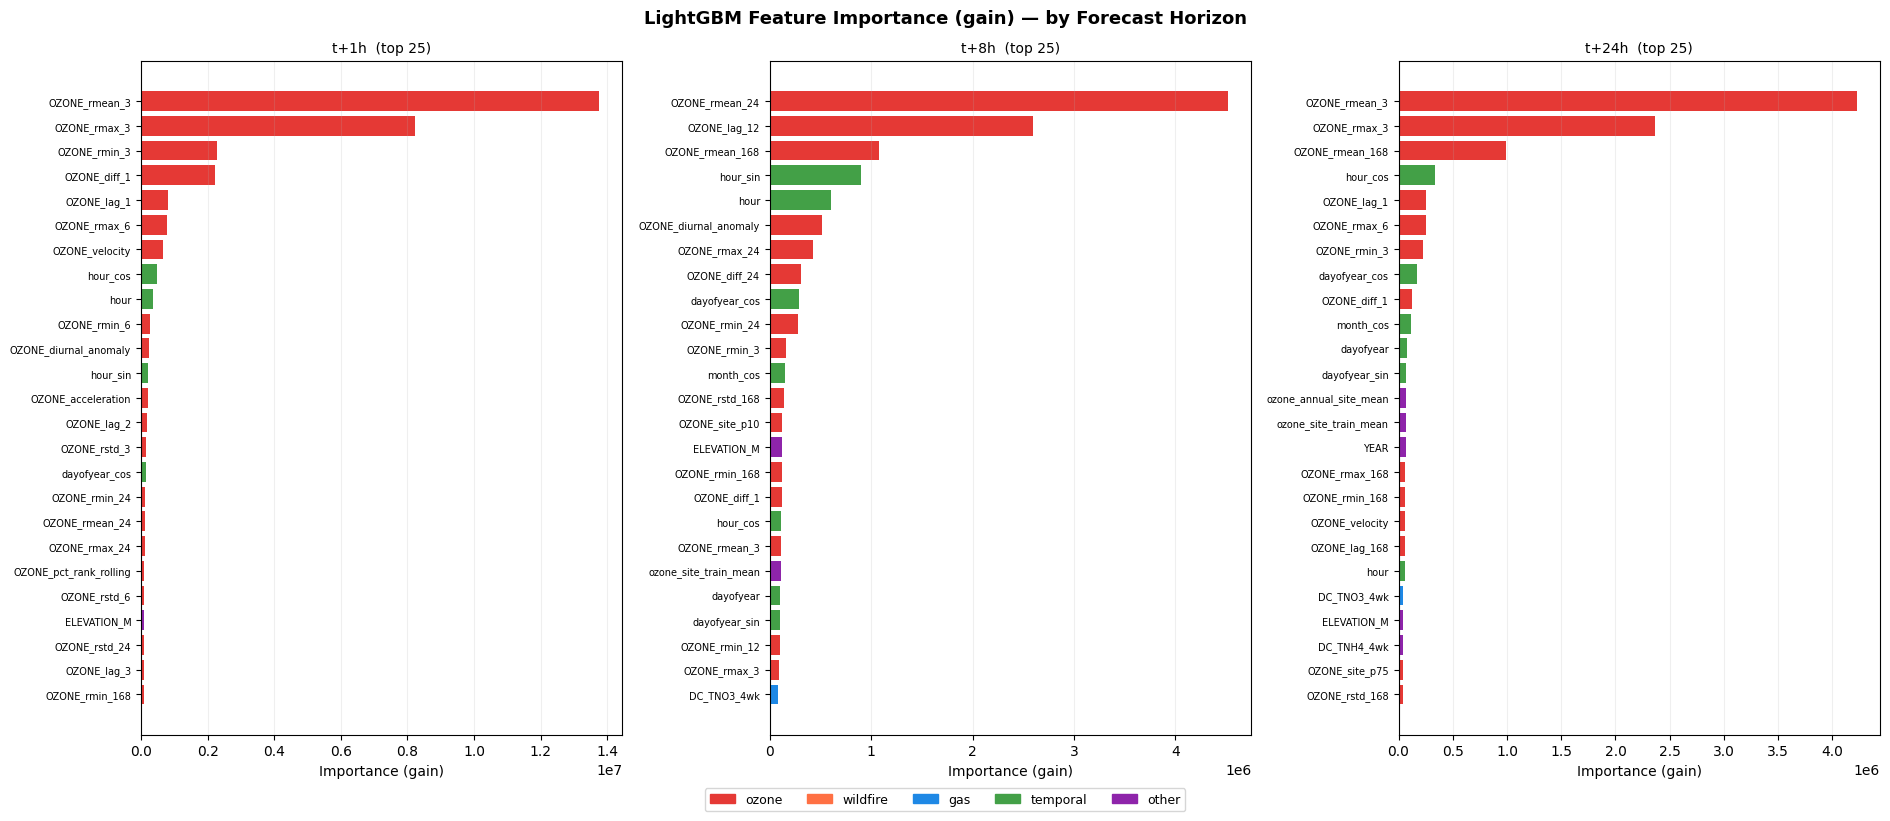


Top-20 features shared across all 3 horizons (6):
  OZONE_diff_1
  OZONE_rmean_3
  OZONE_rmin_3
  dayofyear_cos
  hour
  hour_cos


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 8))
fig.suptitle('LightGBM Feature Importance (gain) — by Forecast Horizon',
             fontsize=13, fontweight='bold')

importance_records = {}
COLOR_MAP = {
    'ozone'   : '#E53935',  # Ozone lags/rolling
    'wildfire': '#FF7043',  # PM2.5 / wildfire / smoke
    'gas'     : '#1E88E5',  # NOx / gas precursors
    'temporal': '#43A047',  # hour / month / season
    'other'   : '#8E24AA',
}

def feat_color(name):
    if 'OZONE' in name:
        return COLOR_MAP['ozone']
    if any(x in name for x in ['PM25','smoke','wildfire','fire']):
        return COLOR_MAP['wildfire']
    if any(x in name for x in ['NO','NOY','NOX','HNO3','SO2','CO']):
        return COLOR_MAP['gas']
    if any(x in name for x in ['hour','month','day','season','year','sin','cos']):
        return COLOR_MAP['temporal']
    return COLOR_MAP['other']

for ax, H in zip(axes, CONFIG['horizons']):
    imp = pd.Series(
        reg_models[H].feature_importance(importance_type='gain'),
        index=reg_models[H].feature_name()
    ).sort_values(ascending=False).head(25)
    importance_records[H] = imp

    cols = [feat_color(c) for c in imp.index]
    ax.barh(imp.index[::-1], imp.values[::-1], color=cols[::-1])
    ax.set_title(f't+{H}h  (top 25)', fontsize=10)
    ax.set_xlabel('Importance (gain)')
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.2, axis='x')

legend_items = [Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
fig.legend(handles=legend_items, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
imp_fig = os.path.join(OUTPUT_DIR, 'feature_importance_by_horizon.png')
plt.savefig(imp_fig, dpi=150, bbox_inches='tight')
print(f'Saved -> {imp_fig}')
plt.show()

# Features shared in top-20 across ALL 3 horizons
shared = set.intersection(*[
    set(importance_records[H].head(20).index) for H in CONFIG['horizons']
])
print(f'\nTop-20 features shared across all 3 horizons ({len(shared)}):')
for feat in sorted(shared):
    print(f'  {feat}')


## Section 13: Save Models & Evaluation Artefacts

In [16]:
print('Saving models and artefacts...')
print('=' * 65)

# Regression models
for H in CONFIG['horizons']:
    mp = os.path.join(OUTPUT_DIR, f'lgb_reg_t{H}.txt')
    reg_models[H].save_model(mp)
    print(f'  lgb_reg_t{H}.txt  ({os.path.getsize(mp)/1024:.0f} KB)')

# Classification model
if clf_model is not None:
    cp = os.path.join(OUTPUT_DIR, 'lgb_clf_naaqs_t8.txt')
    clf_model.save_model(cp)
    print(f'  lgb_clf_naaqs_t8.txt  ({os.path.getsize(cp)/1024:.0f} KB)')

# Evaluation bundle
eval_bundle = {
    'config'            : CONFIG,
    'reg_eval'          : reg_eval,
    'baseline_results'  : baseline_results,
    'clf_eval'          : clf_eval,
    'site_eval'         : site_eval,
    'feature_importance': importance_records,
    'feature_cols'      : FEATURE_COLS_EXT,
    'ca_sites'          : ca_sites,
    'best_clf_threshold': best_thr,
    'generated'         : datetime.now().isoformat(),
}
ep = os.path.join(OUTPUT_DIR, 'eval_results.pkl')
with open(ep, 'wb') as f:
    pickle.dump(eval_bundle, f)
print(f'  eval_results.pkl')

# Final summary
print('\n' + '=' * 80)
print('STEP 4 COMPLETE')
print('=' * 80)
print(f'  Horizons     : {CONFIG["horizons"]} hours')
print(f'  Train        : start -> {CONFIG["train_end"]}')
print(f'  Val          : {CONFIG["val_start"]} -> {CONFIG["val_end"]}')
print(f'  Test         : {CONFIG["test_start"]} -> end')
print()
print(f'  {"Horizon":<10}  {"Val MAE":>9}  {"Val R2":>8}  '
      f'{"Test MAE":>10}  {"Test R2":>9}  {"vs Persist":>12}')
print('-' * 70)
for H in CONFIG['horizons']:
    v  = reg_eval[H]['val']
    t  = reg_eval[H]['test']
    bp = baseline_results[H]['persistence']['mae']
    vs = f'{(1 - v["mae"]/bp)*100:+.1f}%'
    print(f'  t+{H:>2d}h      {v["mae"]:>9.3f}  {v["r2"]:>8.4f}  '
          f'{t["mae"]:>10.3f}  {t["r2"]:>9.4f}  {vs:>12}')

if clf_eval:
    print(f'\n  NAAQS clf t+8  Val AUC={clf_eval["val"]["auc"]:.4f}  '
          f'F1={clf_eval["val"]["f1"]:.4f}  Thr={clf_eval["best_threshold"]:.3f}')
    if clf_eval['test']['auc']:
        print(f'               Test AUC={clf_eval["test"]["auc"]:.4f}  '
              f'F1={clf_eval["test"]["f1"]:.4f}')

print(f'\n  Models saved to : {OUTPUT_DIR}')
print(f'  Next: model_training.ipynb')
print(f'  - Load models from eval_results.pkl')
print(f'  - t+8 NAAQS classification is the primary regulatory output')
print(f'  - Threshold for NAAQS alert = {best_thr:.3f} (val-optimised)')


Saving models and artefacts...
  lgb_reg_t1.txt  (22679 KB)
  lgb_reg_t8.txt  (9336 KB)
  lgb_reg_t24.txt  (2383 KB)
  lgb_clf_naaqs_t8.txt  (1220 KB)
  eval_results.pkl

STEP 4 COMPLETE
  Horizons     : [1, 8, 24] hours
  Train        : start -> 2018-12-31
  Val          : 2019-01-01 -> 2020-12-31
  Test         : 2021-01-01 -> end

  Horizon       Val MAE    Val R2    Test MAE    Test R2    vs Persist
----------------------------------------------------------------------
  t+ 1h          1.646    0.9649       1.621     0.9648        +21.6%
  t+ 8h          4.469    0.7937       4.379     0.7917        +50.6%
  t+24h          5.412    0.7089       5.304     0.7071        +14.1%

  NAAQS clf t+8  Val AUC=0.9863  F1=0.6079  Thr=0.713
               Test AUC=0.9853  F1=0.5799

  Models saved to : C:\MATH699P\Data\processed_data\california\features_parquet\model_prep
  Next: model_training.ipynb
  - Load models from eval_results.pkl
  - t+8 NAAQS classification is the primary regulatory o

In [17]:
# ── DASHBOARD EXPORT ──────────────────────────────────────────
import json
from pathlib import Path

DASH_DIR = Path(r"C:\Users\snehi\Downloads\castnet_streamlit_dashboard\castnet_streamlit\dashboard_data")
DASH_DIR.mkdir(exist_ok=True)

# ── Model metrics: site_eval = {H: {sid: {mae, rmse, r2, n}}} ─────────────────
metrics_export = {}
for sid in ca_sites:
    metrics_export[sid] = {}
    for H in CONFIG['horizons']:
        e = site_eval.get(H, {}).get(sid)
        if e:
            metrics_export[sid][str(H)] = {
                "mae" : round(float(e.get("mae",  0)), 4),
                "rmse": round(float(e.get("rmse", 0)), 4),
                "r2"  : round(float(e.get("r2",   0)), 4),
                "n"   : int(e.get("n", 0)),
            }

with open(DASH_DIR / "model_metrics.json", "w") as f:
    json.dump(metrics_export, f, indent=2)

# ── Feature importance: importance_records = {H: pd.Series(gain, index=feat)} ──
# Feature group classification (mirrors ca_evaluation_gaps.ipynb)
def _feat_group(name):
    if any(k in name for k in ['OZONE_lag','OZONE_rmean','OZONE_diff','OZONE_rmin','OZONE_rmax']):
        return 'Autoregressive (lag/rmean)'
    if any(k in name for k in ['hour','month','day','season','year','sin','cos','weekend',
                                'fire_season','summer','night','photo','post_2017','trend']):
        return 'Calendar / Static'
    return 'Met / Chem / PM'

feat_imp_export = {}
for H in CONFIG['horizons']:
    if H not in importance_records:
        continue
    s = importance_records[H]
    s = s / s.sum()   # normalise to fractions
    groups = {'Autoregressive (lag/rmean)': 0.0,
              'Met / Chem / PM': 0.0,
              'Calendar / Static': 0.0}
    for feat, val in s.items():
        groups[_feat_group(feat)] += float(val)
    feat_imp_export[str(H)] = {k: round(v * 100, 2) for k, v in groups.items()}

with open(DASH_DIR / "feature_importance.json", "w") as f:
    json.dump(feat_imp_export, f, indent=2)

# ── Classifier threshold ───────────────────────────────────────────────────────
clf_meta = {
    "best_threshold"     : round(float(best_thr), 4),
    "val_auc"            : round(float(clf_eval.get("val", {}).get("auc",  0)), 4),
    "val_f1"             : round(float(clf_eval.get("val", {}).get("f1",   0)), 4),
    "test_auc"           : round(float(clf_eval.get("test",{}).get("auc",  0) or 0), 4),
    "naaqs_threshold_ppb": CONFIG['naaqs_threshold'],
}
with open(DASH_DIR / "clf_metadata.json", "w") as f:
    json.dump(clf_meta, f, indent=2)

# ── Pipeline status ────────────────────────────────────────────────────────────
status = {}
try:
    with open(DASH_DIR / "pipeline_status.json") as f:
        status = json.load(f)
except FileNotFoundError:
    pass
status["model_training"] = {
    "status"    : "complete",
    "timestamp" : pd.Timestamp.now().isoformat(),
    "sites"     : ca_sites,
    "horizons"  : CONFIG['horizons'],
    "train_end" : CONFIG['train_end'],
    "val_end"   : CONFIG['val_end'],
    "test_start": CONFIG['test_start'],
}
with open(DASH_DIR / "pipeline_status.json", "w") as f:
    json.dump(status, f, indent=2)

print("✅ Model training exported to dashboard_data/")


✅ Model training exported to dashboard_data/
